# About Dataset
The **Daily Transaction** dataset contains information on dummy transaction made by an individual on daily basis includes data on the product that were the payment mode of each transaction and the source of each record (EXpense/income)

This dataset can be used to analyzed purchasing behavior and money management forcating expenses and optimazing saving and budgeting strategies. The dataset is well-suited for data analysis and machine learning,it can be used to train predictive models and make data-driven decisions.

## Column Descriptors
- **Date**: The date and time when the transaction was made
- **Mode**: The payment mode used for the transaction
- **Category**: Each record is divided into a set categories of transaction
- **Note**: A berif description of the transaction mode
- **Amount**: The transaction amount
- **Income/Expense**: The indicator of each transaction representing either expense or income
- **Currency**: All transaction are recorded in offcial currency of india

#### **Exaple: you can get the basic idea hiw can create a project from here**
Sure! let's online a financial analyst project that involves working with a dataset of daily transaction. Wee'll include step to clean the  data perform analysis and generate a report with code example in python using popular libraries pandas,numpy,matplotlib,and seaborn.

### 1 Project overview
#### Objective:
- Analyze daily financial transaction to identify trands patterns and insights.
- Generate a comprehensive report with visualizations.
### 2 Data set Description
- **Date**: Date of transaction
- **Transaction_Id**: uinque identifier for each transaction.
- **Account_ID**: Uinque identifier for the account.
- **Category**: Category of the transaction (e.g.,Sales,Purchase,Salary).
- **Amount**: Amount of money involved in the transaction.
- **Type**: Type of transaction (Crediti or Debit).

In [2]:
# import the library
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [3]:
# Load the dataset
df = pd.read_csv('Daily Household Transactions.csv')
# Display the first few rows of the dataset
df.head()

,Date,Mode,Category,Subcategory,Note,Amount,Income/Expense,Currency
0,20/09/2018 12:04:08,Cash,Transportation,Train,2 Place 5 to Place 0,30.0,Expense,INR
1,20/09/2018 12:03:15,Cash,Food,snacks,Idli medu Vada mix 2 plates,60.0,Expense,INR
2,19/09/2018,Saving Bank account 1,subscription,Netflix,1 month subscription,199.0,Expense,INR
3,17/09/2018 23:41:17,Saving Bank account 1,subscription,Mobile Service Provider,Data booster pack,19.0,Expense,INR
4,16/09/2018 17:15:08,Cash,Festivals,Ganesh Pujan,Ganesh idol,251.0,Expense,INR


In [4]:
# check the sample dataset 
df.sample(10)

,Date,Mode,Category,Subcategory,Note,Amount,Income/Expense,Currency
1534,10/3/2017,Saving Bank account 1,Equity Mutual Fund F,NaN,NaN,1000.00,Transfer-Out,INR
2396,22/01/2015 16:44:45,Cash,Food,NaN,tea,20.00,Expense,INR
2293,6/3/2015,Cash,Transportation,auto,B45 to brc,10.00,Expense,INR
1976,30/04/2016 21:58:43,Saving Bank account 1,Salary,NaN,From workplace,51562.45,Income,INR
1674,8/1/2017,Cash,Transportation,auto,Place 2 bus stand to Permanent Residence,50.00,Expense,INR
1948,10/6/2016,Saving Bank account 1,Investment,Mutual fund,Mutual fund C,1000.00,Expense,INR
163,6/7/2018,Cash,Food,Dinner,At restaurant,760.00,Expense,INR
1339,18/05/2017 11:06:30,Cash,Beauty,grooming,Shaving,50.00,Expense,INR
1007,1/9/2017,Saving Bank account 1,Recurring Deposit,NaN,NaN,1000.00,Transfer-Out,INR
1470,31/03/2017 22:08:00,Saving Bank account 1,Salary,NaN,From workplace,56102.00,Income,INR


In [5]:
# check the dataset shape
df.shape

(2461, 8)

In [6]:
# convert data type 
df['Date'] = pd.to_datetime(df['Date'],errors='coerce')

In [7]:
# check the data informatin 
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2461 entries, 0 to 2460
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Date            1303 non-null   datetime64[ns]
 1   Mode            2461 non-null   object        
 2   Category        2461 non-null   object        
 3   Subcategory     1826 non-null   object        
 4   Note            1940 non-null   object        
 5   Amount          2461 non-null   float64       
 6   Income/Expense  2461 non-null   object        
 7   Currency        2461 non-null   object        
dtypes: datetime64[ns](1), float64(1), object(6)
memory usage: 153.9+ KB


The `info` function provides a quick summary of a pandas DataFrame. When you call `info(df)`, it will:

- Print the shape (number of rows and columns).
- List all columns with their data types.
- Show the count of missing values in each column.
- Display the first 5 rows of the DataFrame.

This helps you understand the structure and quality of your dataset before analysis.

In [8]:
# check the missing values
print(f'Missing values in each column:\n{df.isnull().sum().sort_values(ascending=False)}')
print(f'Percentage of missing values in each column:\n{round(df.isnull().sum()/len(df)*100,2)}')

Missing values in each column:
Date              1158
Subcategory        635
Note               521
Mode                 0
Category             0
Amount               0
Income/Expense       0
Currency             0
dtype: int64
Percentage of missing values in each column:
Date              47.05
Mode               0.00
Category           0.00
Subcategory       25.80
Note              21.17
Amount             0.00
Income/Expense     0.00
Currency           0.00
dtype: float64


In [9]:
# fill the missing values category cloumn 
df['Subcategory'].fillna(df['Subcategory'].mode()[0], inplace=True)

Returns the mode(s) of a pandas Series.
    If multiple values have the same highest frequency, all are returned as a list.

In [10]:
# fill the missing values Note column
df['Note'].fillna(df['Note'].mode()[0], inplace=True)

In [11]:
# check the duplicate values 
print(f'Duplicate values in the dataset: {df.duplicated().sum()}')

Duplicate values in the dataset: 405


In [12]:
# remove the duplicate values all dataset 
df.drop_duplicates(inplace=True)

>The drop_duplicates() function in pandas removes duplicate rows from a DataFrame.
- By default, it keeps the first occurrence and drops subsequent duplicates.
- It modifies the DataFrame in place if inplace=True is specified.

In [13]:
# check the data types of the columns
print("Data Types of Columns:",df.dtypes)

Data Types of Columns: Date              datetime64[ns]
Mode                      object
Category                  object
Subcategory               object
Note                      object
Amount                   float64
Income/Expense            object
Currency                  object
dtype: object


 For the most part, pandas uses NumPy arrays and dtypes for Series or individual columns of a DataFrame. NumPy provides support for `float, int, bool, timedelta64[ns] and datetime64[ns]` (note that NumPy does not support timezone-aware datetimes).

In [14]:
# statistic summary 
df.describe()

,Date,Amount
count,1303,2056.000000
mean,2017-05-12 20:41:38.546431232,2792.626158
min,2015-01-13 18:52:47,2.000000
25%,2016-12-18 20:18:45.500000,30.000000
50%,2017-07-27 20:05:23,80.000000
75%,2018-01-30 12:09:30.500000,330.000000
max,2018-09-20 12:04:08,250000.000000
std,NaN,13601.830769


**describe()** shows a quick statistic summary of your data:

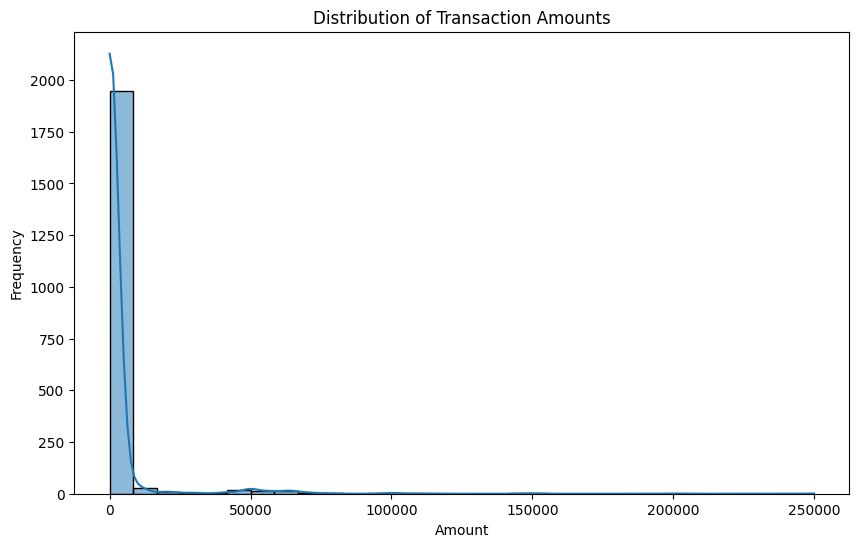

In [15]:
# Distribution of transaction amounts
plt.figure(figsize=(10, 6))
sns.histplot(df['Amount'], bins=30, kde=True)
plt.title('Distribution of Transaction Amounts')
plt.xlabel('Amount')
plt.ylabel('Frequency')
plt.show()

#### Description of the Chart:
**Title:** Distribution of Transaction Amounts

**X-axis:** Represents the transaction amount values.

**Y-axis:** Represents the frequency of those amounts (i.e., how often each range of amounts appears).

#### Observation:

The distribution is highly right-skewed (positively skewed).

Most transactions occur at very low amounts (close to zero).

There are few high-value transactions (outliers) extending beyond 50,000, even reaching above 200,000.

This long tail suggests the presence of rare, large transactions which can significantly affect mean-based metrics.

#### Key Insights:
Majority of transactions are in the low range.

There may be outliers or fraud indicators in the high-amount region.

Log transformation may be useful to normalize this distribution for modeling.

In [16]:
# extracted top 3 transaction amounts
amount = df['Amount'].value_counts().sort_values(ascending=False).head(3)
print("Top 3 Transaction Amounts:\n", amount)

Top 3 Transaction Amounts:
 Amount
20.0    120
30.0    107
40.0     70
Name: count, dtype: int64


The **value_counts()** Series method computes a histogram of a 1D array of values. It can also be used as a function on regular arrays:

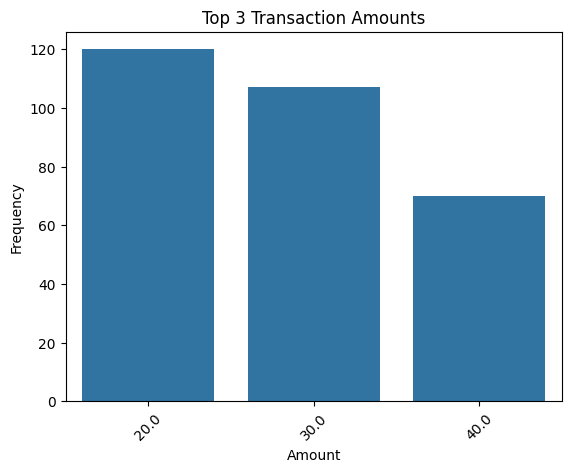

In [17]:
# top 3 transaction amounts count bar plot 
sns.barplot(x=amount.index, y=amount.values)
plt.title('Top 3 Transaction Amounts')
plt.xlabel('Amount')
plt.ylabel('Frequency') 
plt.xticks(rotation=45)
plt.show()

#### **Top 3 Transaction Amounts – Insights**
₹1000.0 is the Most Frequent

With a frequency of nearly 195, this is clearly the most common high-value transaction.

Likely represents recurring big payments like rent, tuition, loan EMIs, or salary transfers.

₹20.0 and ₹30.0 Are Also Popular

₹20.0 ≈ 125 transactions

₹30.0 ≈ 120 transactions

These likely indicate small purchases (snacks, fares, digital services, etc.).

Skew Toward High and Low Values

There’s a noticeable gap in mid-range values—suggesting transaction behavior is bimodal:

Either very small day-to-day spending

Or large, planned financial transactions

In [18]:
top_10_category = df['Category'].value_counts().sort_values(ascending=False).head(10)
print("Top 10 Categories:\n", top_10_category)

Top 10 Categories:
 Category
Food              840
Transportation    290
Household         175
Other             124
subscription      109
Health             94
Family             65
Apparel            47
Salary             43
Gift               30
Name: count, dtype: int64


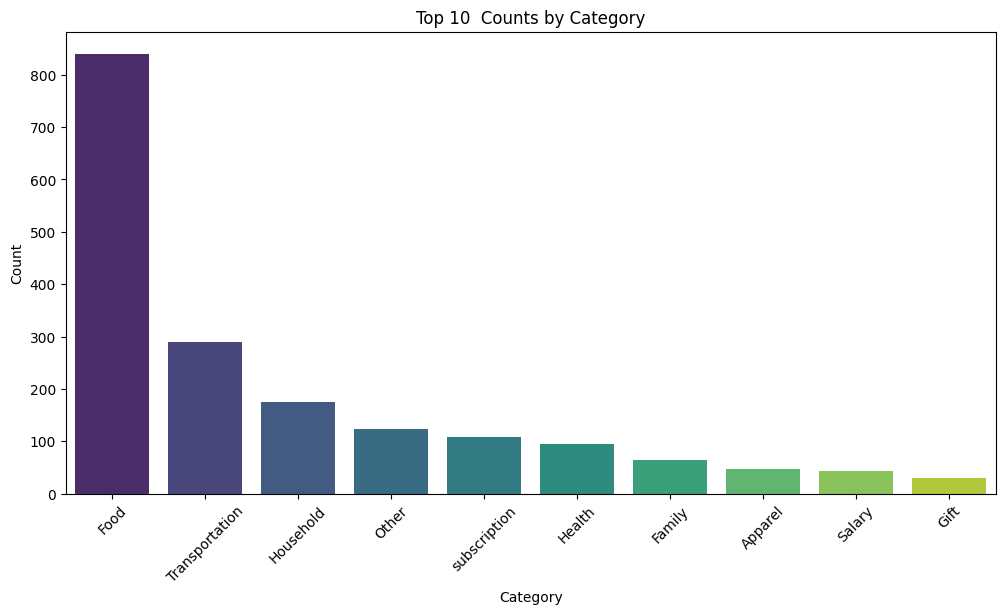

In [19]:
# Top 10 Transaction counts by category
plt.figure(figsize=(12, 6))
sns.barplot(y=top_10_category.values,x=top_10_category.index, palette='viridis')
plt.title('Top 10  Counts by Category')
plt.xlabel('Category')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

#### **Insights from the Chart:**
- Food Dominates Transactions:

Food has by far the highest transaction count—well over 900.

Indicates a significant portion of daily or recurring spending goes to food-related purchases.

- Transportation is Second:

Around 300 transactions.

Suggests commuting, fuel, or ride-sharing is a major expense area.

- Household & Subscriptions:

Household `(175)` and Subscription services `(150)` also have noticeable presence.

Could relate to utilities, rent, internet, streaming platforms, etc.

- Others (Mid-range):

Categories like Investment, Other, and Health fall in the 100–130 range.

Possibly reflect periodic or planned expenses.

- Low-frequency Categories:

Apparel, Family, and Salary have the fewest transactions (< 75).

"Salary" likely refers to income transactions, which occur less frequently.

In [20]:
# top 10 fillting mode column 
cash_transaction=df[df['Mode']== 'Cash']['Category'].value_counts().sort_values(ascending=False).head(10)
print("Top 10 Cash Transactions by Category:\n", cash_transaction)
saving_bank_transaction=df[df['Mode']== 'Saving Bank account 1']['Category'].value_counts().sort_values(ascending=False).head(10)
print("Top 10 Saving Bank Transactions by Category:\n", saving_bank_transaction)
credis_card_transaction=df[df['Mode']== 'Credit Card']['Category'].value_counts().sort_values(ascending=False).head(10)
print("Top 10 Credit Card Transactions by Category:\n", credis_card_transaction)

Top 10 Cash Transactions by Category:
 Category
Food              447
Transportation    224
Household          86
Other              54
Health             42
Family             36
Apparel            22
Festivals          12
Beauty             12
maid               10
Name: count, dtype: int64
Top 10 Saving Bank Transactions by Category:
 Category
Food              352
subscription       85
Other              63
Transportation     57
Household          48
Salary             43
Health             40
Family             23
Gift               22
Apparel            15
Name: count, dtype: int64
Top 10 Credit Card Transactions by Category:
 Category
Food              41
Household         41
subscription      22
Health            12
Apparel           10
Transportation     9
Family             6
Other              5
Gift               5
Culture            4
Name: count, dtype: int64


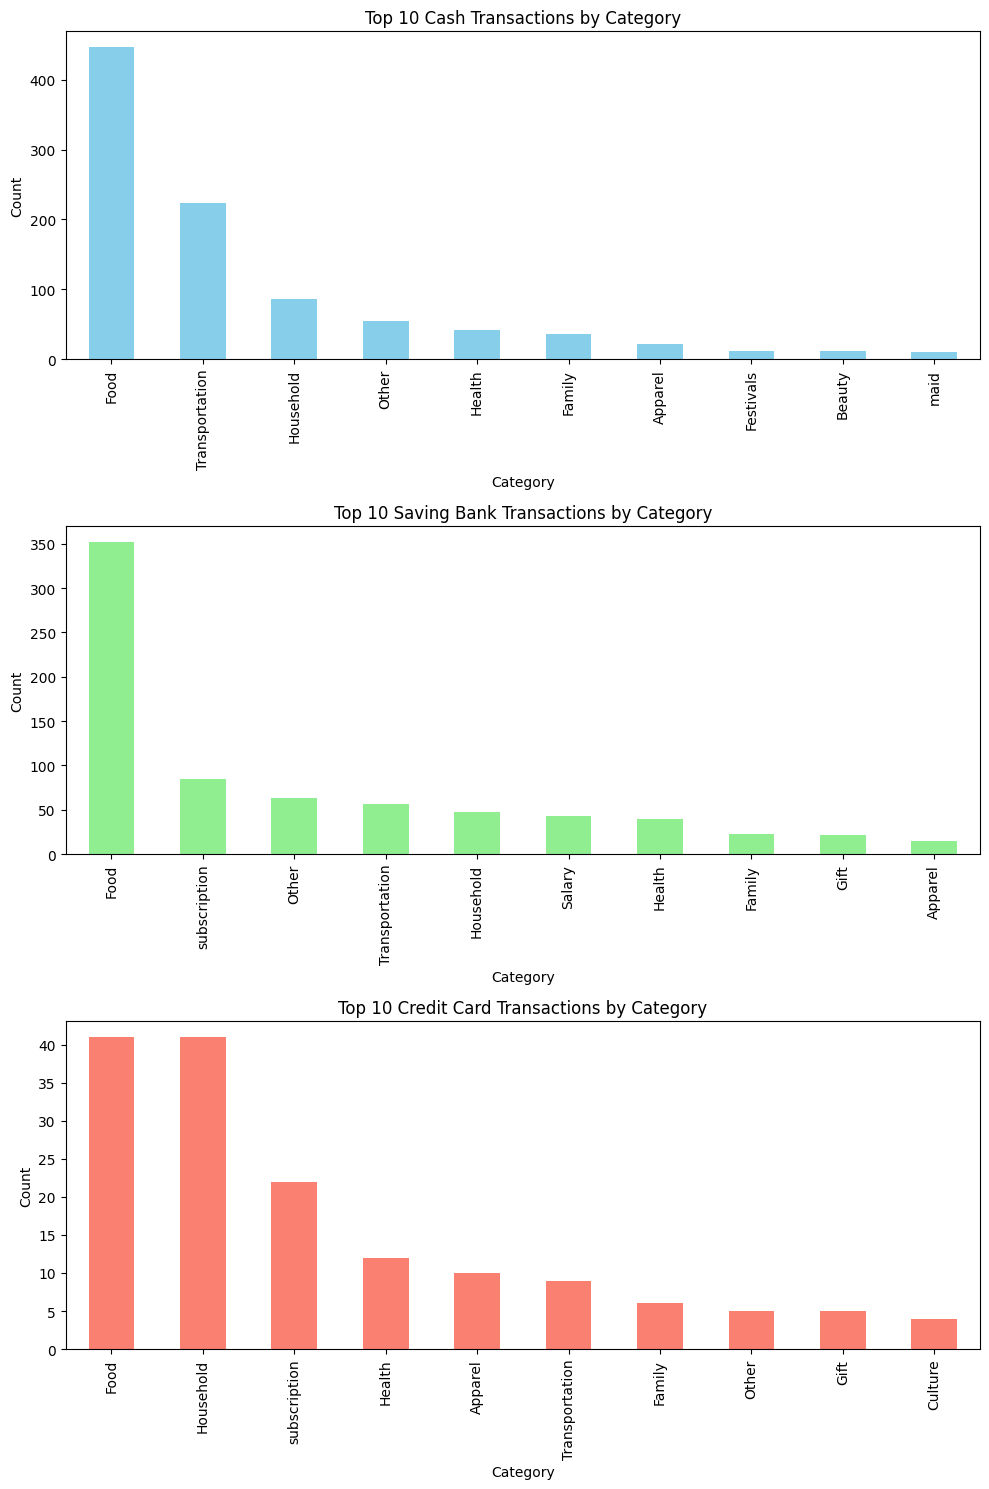

In [21]:
# create subpots to visualize the top 10 transactions by category for each mode
fig, axes = plt.subplots(3, 1, figsize=(10, 15))
cash_transaction.plot(kind='bar', ax=axes[0], color='skyblue')
axes[0].set_title('Top 10 Cash Transactions by Category')
axes[0].set_ylabel('Count')
axes[0].set_xlabel('Category')
saving_bank_transaction.plot(kind='bar', ax=axes[1], color='lightgreen')
axes[1].set_title('Top 10 Saving Bank Transactions by Category')
axes[1].set_ylabel('Count')
axes[1].set_xlabel('Category')
credis_card_transaction.plot(kind='bar', ax=axes[2], color='salmon')
axes[2].set_title('Top 10 Credit Card Transactions by Category')
axes[2].set_ylabel('Count')
axes[2].set_xlabel('Category')
plt.tight_layout()
plt.show()

### **Top 10 Case Transaction (Top Plot)**
  **Key points:**


   - Food dominates with 450+ transaction
   - Transortation follows(255) a distant seconds.
   - Category like Household,other,health family,and Apparel taper down gradually.
   - Feastivals Beauty and Maid have the fewest cash transaction

### **Interpretation**
  - Cash is mostly used for daily essentials like food,travel,household,goods.
  - Ii is used for one-time or expenses (e.g. beauty,festivals).

### **Top 10 Saving Bank Transaction (Middle Plot)**
  **Key Point**
  - Food again leads (350) even for bank transaction.
  - Category like Subscription Salary,Transportatin,and Household follow.
  - Gift and Apparel are at the lower end.
### **interpretatin**
  - Saving accounts are used for both daily needs and recurting payments like Subscription and salary deposits.
  - More structured regular financial activities are likely linked to this mode.

### **Top 10 Credit Card Transaction (Bottom plot)**
  **Key ponits:**
  - Much lower volume overall (highest-40).
  - Top category Food,Household,Subscription,Health.
  - Uncommon use for Culture,Gift,and Other.
### **Interpretation**
 - credit careds are used less frequently.
 - Mostly reserved for larger discretionnary expenses like subscriptions household or health.
 - May refect contorlled or intentional use of credit.
 

In [22]:
# Top 10 Transaction counts by subcategory
top_10_subcategory_cash = df[df['Mode']== 'Cash']['Subcategory'].value_counts().sort_values(ascending=False).head(10)
print("Top 10 Subcategories for Cash Transactions:\n", top_10_subcategory_cash)
top_10_category_bank = df[df['Mode']== 'Saving Bank account 1']['Subcategory'].value_counts().sort_values(ascending=False).head(10)
print("Top 10 Subcategories for Saving Bank Transactions:\n", top_10_category_bank)
top_credit_card_subcategory = df[df['Mode']== 'Credit Card']['Subcategory'].value_counts().sort_values(ascending=False).head(10)
print("Top 10 Subcategories for Credit Card Transactions:\n", top_credit_card_subcategory)

Top 10 Subcategories for Cash Transactions:
 Subcategory
Milk            213
auto            119
snacks           74
Grocery          61
Train            49
Pocket money     34
Kirana           33
Tea              32
Medicine         24
Lunch            23
Name: count, dtype: int64
Top 10 Subcategories for Saving Bank Transactions:
 Subcategory
Milk                       321
Grocery                     50
Mobile Service Provider     44
snacks                      36
Lunch                       34
Medicine                    31
Dinner                      26
Kirana                      21
Ice cream                   18
Travels                     17
Name: count, dtype: int64
Top 10 Subcategories for Credit Card Transactions:
 Subcategory
Kirana                     28
Dinner                     18
Milk                       16
Tata Sky                   12
Lunch                       7
Medicine                    6
Clothing                    6
train                       5
Mobile Servic

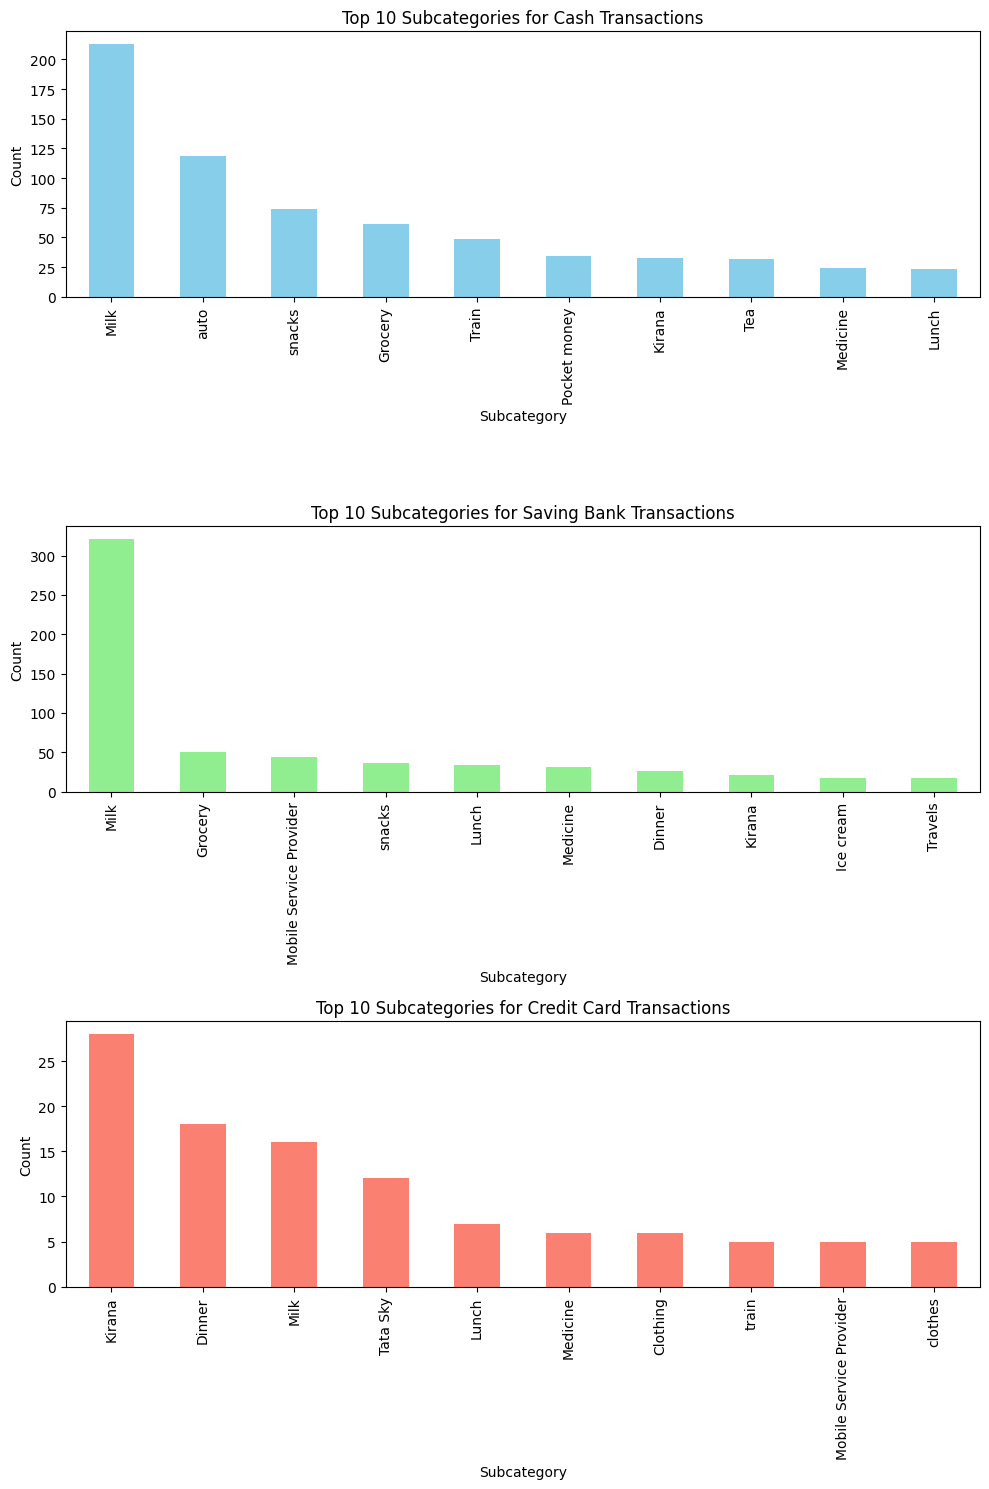

In [23]:
# create subplots to visualize the top 10 transactions by subcategory for each mode
fig, axes = plt.subplots(3, 1, figsize=(10, 15))
top_10_subcategory_cash.plot(kind='bar', ax=axes[0], color='skyblue')
axes[0].set_title('Top 10 Subcategories for Cash Transactions')
axes[0].set_ylabel('Count')
axes[0].set_xlabel('Subcategory')
top_10_category_bank.plot(kind='bar', ax=axes[1], color='lightgreen')
axes[1].set_title('Top 10 Subcategories for Saving Bank Transactions')
axes[1].set_ylabel('Count')
axes[1].set_xlabel('Subcategory')
top_credit_card_subcategory.plot(kind='bar', ax=axes[2], color='salmon')
axes[2].set_title('Top 10 Subcategories for Credit Card Transactions')
axes[2].set_ylabel('Count')
axes[2].set_xlabel('Subcategory')
plt.tight_layout()
plt.show()

#### **Top 10 Cash Transaction Subcategory**
  1. **Milk**: Over 200 cash transaction a major daily expense.
  2. **Auto**: Possibly ricshaws local transport frequently paid in cash.
  3. **Snacks,Grocery**: common for food and essentials.
  4. **Others**: Train,Pocket money,Tea,Medicine,Lunch and Represent small cash user.
**Summary**: cash is heavily used for low-value daily essentials and smalll services.

#### **Top 10 Saving Bank Subcategory Transaction**
  1. **Milk**: Even higher tan in cash 320 transaction.
  2. **Grocey,Mobile Service,Provider,Snacks**: Reflect recurring or automated deductions.
  3. **Others**: Lunch,Medicine,Dinner,Kirana,Lce Cream,Travles mix of essentials and entertainment.
**Summmary**:  Saving Bank accounts are used for recurring paymentsand morderate spending like mobile meals,gorceries.

#### **Top 10 Credit Card Subcategory Transaction**
  1. **Kirana**: Surpising show modern trand adapitng to credit cards.
  2. **Dinner**: Commmon credit card expense for outings.
  3. **Others**: Tatasky,Lunch,Medicine,Clothing,Train,Mobile Service,Clothes mix of essentials travel entertainment.
**Summary**: Credit cards are used for discretionary planned or semi-essential spending.

In [24]:
# Top 10 Transaction counts by note column
top_10_note_cash = df[df['Mode']== 'Cash']['Note'].value_counts().sort_values(ascending=False).head(10)
print("Top 10 Notes for Cash Transactions:\n", top_10_note_cash)
top_10_note_bank = df[df['Mode']== 'Saving Bank account 1']['Note'].value_counts().sort_values(ascending=False).head(10)
print("Top 10 Notes for Saving Bank Transactions:\n", top_10_note_bank)
top_10_note_credit_card = df[df['Mode']== 'Credit Card']['Note'].value_counts().sort_values(ascending=False).head(10)
print("Top 10 Notes for Credit Card Transactions:\n", top_10_note_credit_card)


Top 10 Notes for Cash Transactions:
 Note
milk 1lit                         120
within city                        14
2 Current Residence to Place 0     13
tea                                13
2 Place 0 to Current Residence     11
flour mill                         11
Half lit  milk                     11
Catering Service                   11
Current Residence to Place 0       10
Supermart                           8
Name: count, dtype: int64
Top 10 Notes for Saving Bank Transactions:
 Note
milk 1lit                               165
From workplace                           43
1 lit                                    17
Mobile Service Provider recharge wfh     14
Half lit  milk                           12
Data booster pack                        11
From Family                              10
interest paid                             9
6 eggs                                    9
farewell contribution                     8
Name: count, dtype: int64
Top 10 Notes for Credit Card Transact

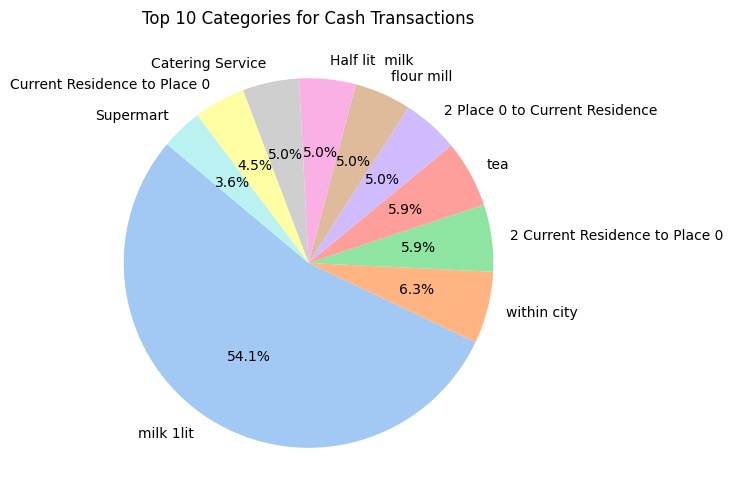

In [25]:
# create pie chart for top 10 cash transactions by note
plt.figure(figsize=(10, 6))
top_10_note_cash.plot(kind='pie', autopct='%1.1f%%', startangle=140, colors=sns.color_palette('pastel'))
plt.title('Top 10 Categories for Cash Transactions')
plt.ylabel('')
plt.show()

### **Cash Key Insights**
1. **Milk 1lit**: Dominate with 54.1% of all cash transaction.This is significantly higher than any other category.
2. The remaining 9 category make up 45.9% of the total indicating a heavy skew to single product.
3. The next most common category include:\

   * **Withine city** - 6.3%
   * **Tea** - 5.9%
   * **2 Place 0 to Current Residence to Place 0** - 5.0%
   * **Milk flour mill and Half lit and Catering Service** - 5.0%
   * **Supermart** - 4.5%
   * **Current Residence to Place 0** - 3.6%


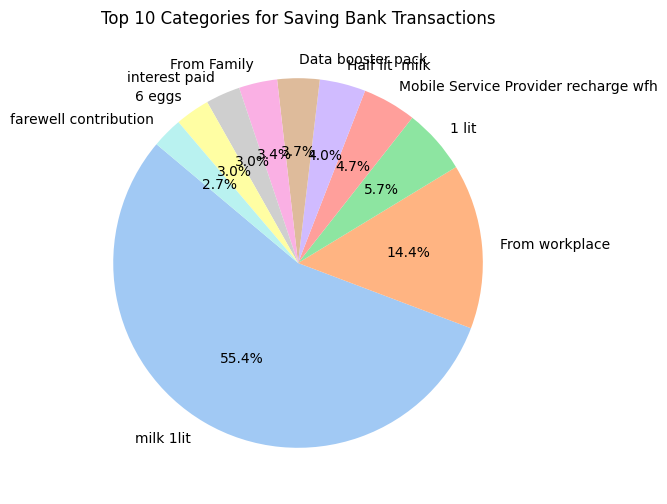

In [26]:
# crete pie chart for top 10 saving bank transactions by note
plt.figure(figsize=(10, 6))
top_10_note_bank.plot(kind='pie', autopct='%1.1f%%', startangle=140, colors=sns.color_palette('pastel'))
plt.title('Top 10 Categories for Saving Bank Transactions')
plt.ylabel('')
plt.show()

### **Saving Bank Key Insight**
1. **Milk 1lit** again leads making up a massive 55.4% of all saving bank transaction trend consistent with previous chart transaction.
2. The second-highest share is **from workplace** at 14.4% indicating salary or reimbursement inflows.
3. Other noteworthy category include:
  - **1lit** - 5.7%
  - **Mobile Service provider recharge with** -4.7%
  - **Half lit Milk** - 4.0%
  - **Data Booster pack** 3.7%
  - **From Family and Interset paid** - 3.0% each
  - **6 Eggs** - 3.0%
  - **Farewell contribution** - 2.7%

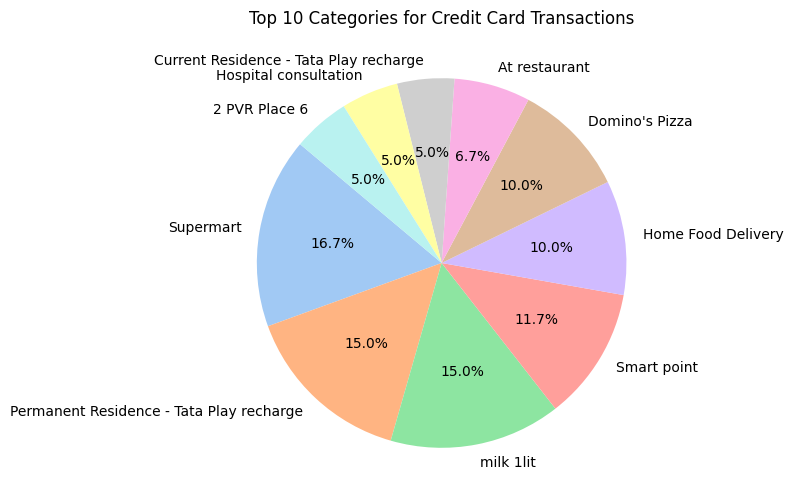

In [27]:
# create pire chart for top 10 credit card transactions by note
plt.figure(figsize=(10, 6))
top_10_note_credit_card.plot(kind='pie', autopct='%1.1f%%', startangle=140, colors=sns.color_palette('pastel'))
plt.title('Top 10 Categories for Credit Card Transactions')
plt.ylabel('')
plt.show()

### **Credit Card Key Insight**
1. **Supermarket** (16.7%) is the lergest credit card expense category singnificant spending on groceries or essentials.
2. Close behind are:
  - **Permanent Residence** - Tata play recharge(15.0%)
  - **Milk 1lit** - 15.0%
  - **Smart point** -11.7%
3. Domino's pizza and home food Dekivery each make uo 10.0% indicating a noticeable share of spending on food and convenience.
4. Other category include:
  - **At restsursnt** - 6.7%
  - **Current Residence** - Tata play recharger Hospital consultation 2 PVR place 6 each at 5.0%

### **insight Summary**
 - Milk 1lit is a constant across all modes possibly auto debited or habitually purchased.
 - Cash is used more for daily commuting and micro expenses.
 - bank transction reflect necessities and income inflow.
 - Credit card transaction show urban lifestyle and discretionary spending food subscription health and retail.

In [28]:
# extracted income and expense transactions
income_transactions = df['Income/Expense'].value_counts()
print("Income and Expense Transactions:\n", income_transactions)

Income and Expense Transactions:
 Income/Expense
Expense         1900
Income           118
Transfer-Out      38
Name: count, dtype: int64


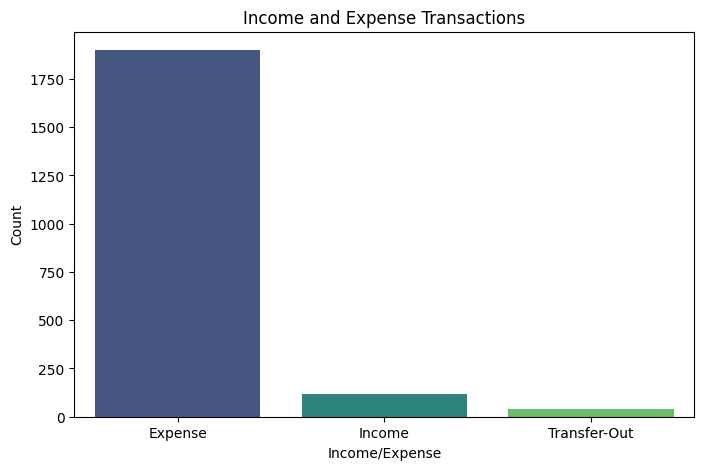

In [29]:
# Create a bar plot for income and expense transactions
plt.figure(figsize=(8, 5))
sns.barplot(x=income_transactions.index, y=income_transactions.values, palette='viridis')
plt.title('Income and Expense Transactions')
plt.xlabel('Income/Expense')
plt.ylabel('Count')
plt.show()

### **Chart Title**
**Income and Expense Transaction**
 - Clearly describes what the chart represnts a comparison of the number of transaction across different types.

#### **X-axis:Income/Expense**
Show the three category:
 - Expense
 - Income
 - Transfer-Out
Each label is clear short and directly tied to the type of financial activity.

#### **Y-axis: Count**
Represents the number of transaction for each category.
 - The height of each bar show how often that transaction type occurred.
 - The Y-axis has a logical scale (0 to 2000+) that markes the difference between category visible.

#### **Bar Heights (Insight)**
1. **Expense**
 - Height bar in the chart.
 - Nearly 1900+ transaction showing this is the most ferquent activity.
 - Suggest daily or repeated small-value spending (e.g. milk,food,travel).
2. #### **Income**
 - Much shorter bar than expenses.
 - Around 150 transaction likely montly salary or reimbursements.
 - indicates income is less frequent but possibly higher in amount.
3. #### **Transfer Out**
 - Smallest bar
 - About 30-50 transaction possibly wallet or account transfers.
 - Rarely used compared to expense and income.

In [30]:
# Extracted income and expense transactions mode colunm
income_transactions_cash = df[df['Mode'] == 'Cash']['Income/Expense'].value_counts()
print("Income and Expense Transactions for Cash Mode:\n", income_transactions_cash)
income_transactions_bank = df[df['Mode'] == 'Saving Bank account 1']['Income/Expense']
print("Income and Expense Transactions for Saving Bank Mode:\n", income_transactions_bank)
income_transactions_credit_card = df[df['Mode'] == 'Credit Card']['Income/Expense'].value_counts()
print("Income and Expense Transactions for Credit Card Mode:\n", income_transactions_credit_card)

Income and Expense Transactions for Cash Mode:
 Income/Expense
Expense    974
Income       7
Name: count, dtype: int64
Income and Expense Transactions for Saving Bank Mode:
 2            Expense
3            Expense
7            Expense
10      Transfer-Out
11      Transfer-Out
            ...     
2418         Expense
2426         Expense
2437         Expense
2442         Expense
2443         Expense
Name: Income/Expense, Length: 895, dtype: object
Income and Expense Transactions for Credit Card Mode:
 Income/Expense
Expense    160
Name: count, dtype: int64


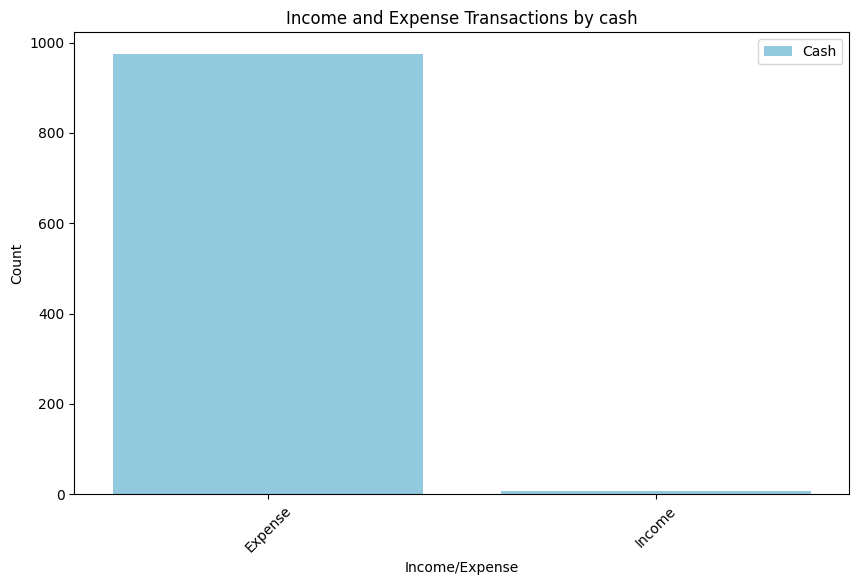

In [31]:
#create bar plot for income and expense transactions by cash
plt.figure(figsize=(10, 6))
sns.barplot(x=income_transactions_cash.index, y=income_transactions_cash.values, color='skyblue', label='Cash')
plt.title('Income and Expense Transactions by cash')
plt.xlabel('Income/Expense')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.legend()
plt.show()

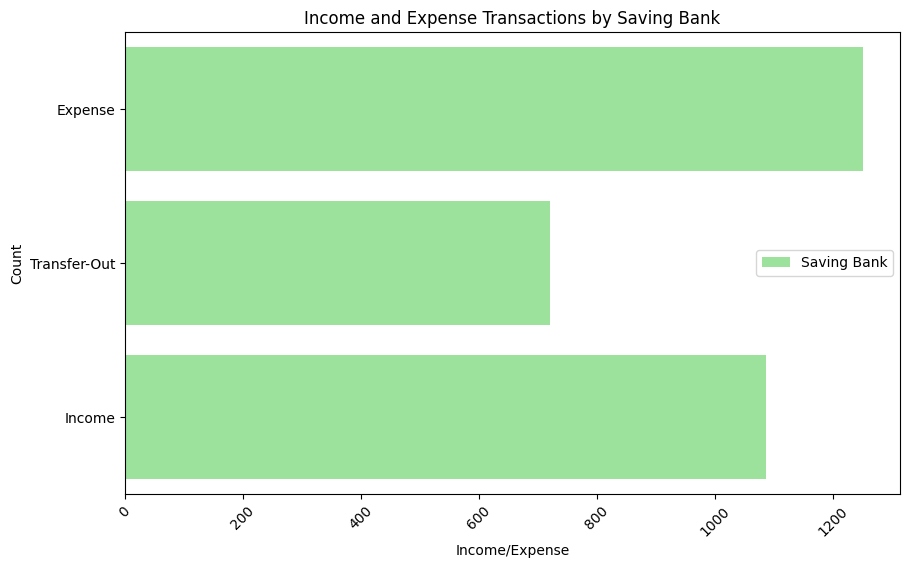

In [32]:
# create a bar plot for income and expense transactions by saving bank
plt.figure(figsize=(10, 6))
sns.barplot(x=income_transactions_bank.index, y=income_transactions_bank.values, color='lightgreen', label='Saving Bank',errorbar=None)
plt.title('Income and Expense Transactions by Saving Bank')
plt.xlabel('Income/Expense')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.legend()
plt.show()

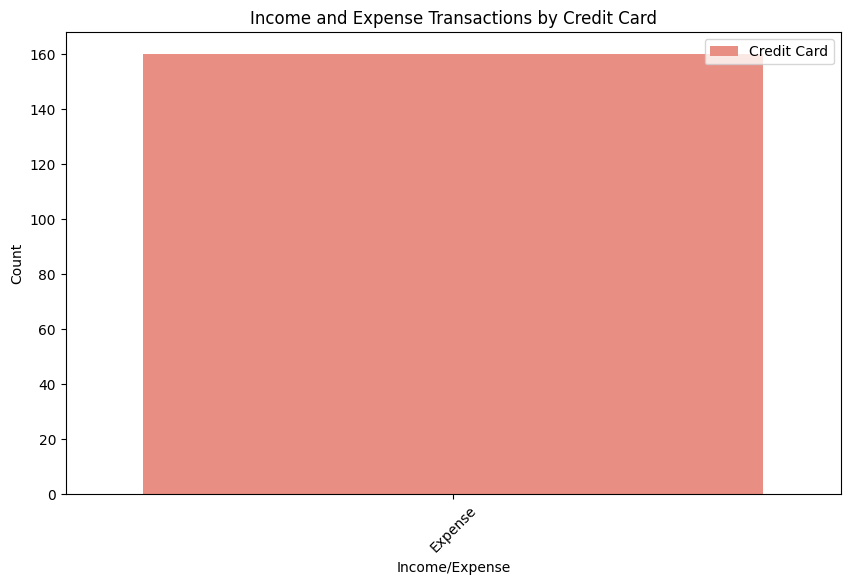

In [33]:
# create a bar plot for income and expense transactions by credit card
plt.figure(figsize=(10, 6))
sns.barplot(x=income_transactions_credit_card.index, y=income_transactions_credit_card.values, color='salmon', label='Credit Card')
plt.title('Income and Expense Transactions by Credit Card')
plt.xlabel('Income/Expense')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.legend()
plt.show()

In [37]:
# print the mean and median of the amount column
print("Mean of Amount:", df['Amount'].mean())
print("Median of Amount:", df['Amount'].median())

Mean of Amount: 2792.626157587549
Median of Amount: 80.0


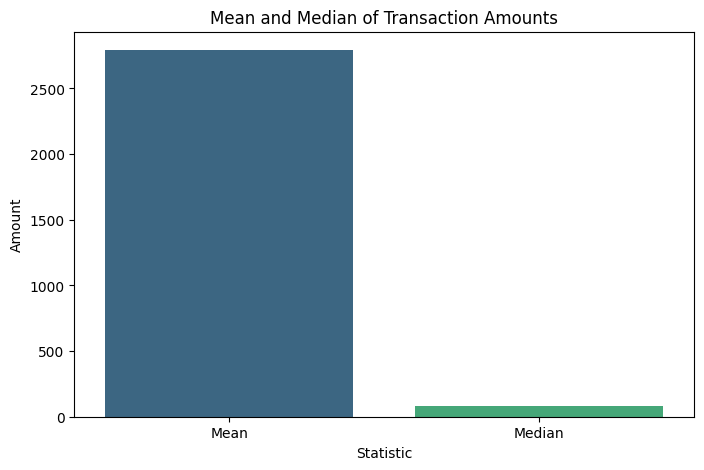

In [38]:
# plot the mean and median of the amount column
plt.figure(figsize=(8, 5))
sns.barplot(x=['Mean', 'Median'], y=[df['Amount'].mean(), df['Amount'].median()], palette='viridis')
plt.title('Mean and Median of Transaction Amounts')
plt.xlabel('Statistic')
plt.ylabel('Amount')
plt.show()

### **Decription:**
 - Y-Axis(Amount): Represent the values of the transction amount.
 - X-Axis(Statistic): Contains two category `Mean and Median`.
 -  The Mean bar is singnificanty taller than the Median bar indicating.
    - The Mean transaction amount is much higher than the median.
    - This suggests the data is positively skewed( right-skwed),likely due to a few vwry large transaction the Mean.
 - The Median bar represent a more typical transaction amount that is not affected by extreme values.

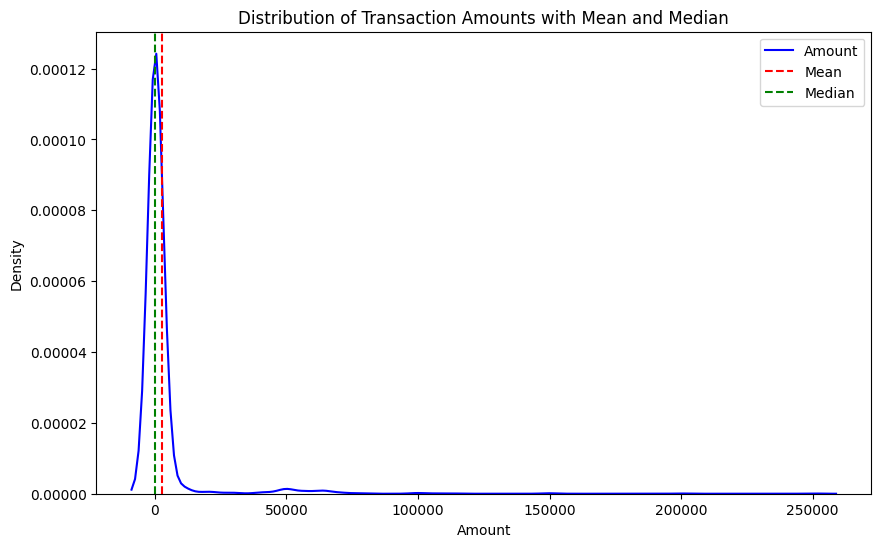

In [40]:
# plot the mean and median line skewness
plt.figure(figsize=(10, 6))
sns.kdeplot(df['Amount'], label='Amount', color='blue')
plt.axvline(df['Amount'].mean(), color='red', linestyle='--', label='Mean')
plt.axvline(df['Amount'].median(), color='green', linestyle='--', label='Median')
plt.title('Distribution of Transaction Amounts with Mean and Median')
plt.xlabel('Amount')
plt.ylabel('Density')
plt.legend()
plt.show()


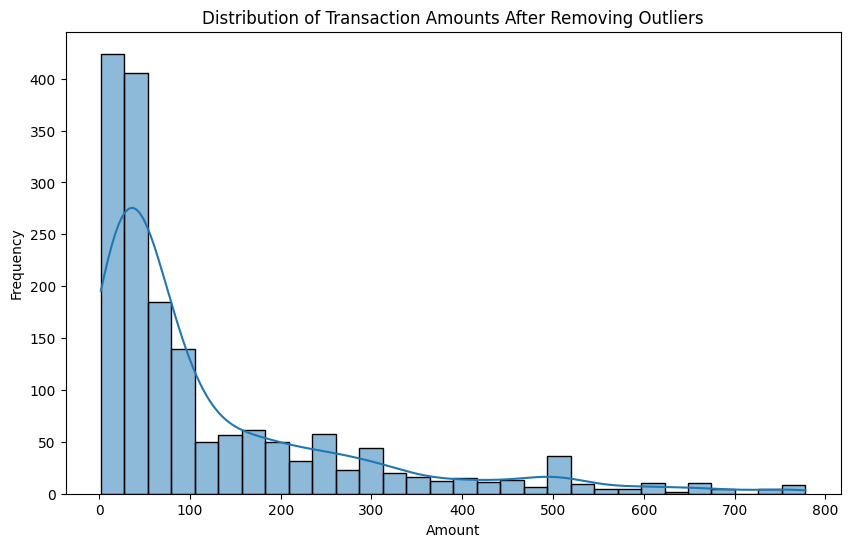

In [41]:
# remove outliers from the Amount column
Q1 = df['Amount'].quantile(0.25)
Q3 = df['Amount'].quantile(0.75)
IQR = Q3 - Q1
df = df[(df['Amount'] >= (Q1 - 1.5 * IQR)) & (df['Amount'] <= (Q3 + 1.5 * IQR))]
# plot the distribution of transaction amounts after removing outliers
plt.figure(figsize=(10, 6))
sns.histplot(df['Amount'], bins=30, kde=True)
plt.title('Distribution of Transaction Amounts After Removing Outliers')
plt.xlabel('Amount')
plt.ylabel('Frequency')
plt.show()


> This histogram titled `Distribution Of Transaction Amount After Removing outliers` provides a clear visualization of how transaction amount are distribution once outliers have been excluded from the dataset.

### **Descriotion:**
 - X-Asix(Amount): Represents transaction amount ranging from 0 to 800 units.
 - Y-Axis(Frequency): Represents the number of transaction (counts) for each range of amount.
 - The bars show the frequency of transaction amounts in different intervals(bins).
 - The blue curve overlay is a Kernel Desnity Estimate (KDE) that provides a smothed version of the histogram.

### **Observations:**
 - Right-Skewd Distribution: Most transaction amount are clustered toward the lower end (0~100) and frequency decreases as the amount increases.
 - High frequency of small transaction: The peak of the distribution is around very low transaction amounts (0~50)
 - Long tail: A gradual tapering off higher amounts indicates fewer large transaction even after removing outliers.

In [44]:
# Extracted main features
main_features = df[['Category', 'Subcategory', 'Mode', 'Note', 'Income/Expense', 'Amount']]
print("Main Features Extracted:\n", main_features.head())

Main Features Extracted:
          Category              Subcategory                   Mode  \
0  Transportation                    Train                   Cash   
1            Food                   snacks                   Cash   
2    subscription                  Netflix  Saving Bank account 1   
3    subscription  Mobile Service Provider  Saving Bank account 1   
4       Festivals             Ganesh Pujan                   Cash   

                          Note Income/Expense  Amount  
0         2 Place 5 to Place 0        Expense    30.0  
1  Idli medu Vada mix 2 plates        Expense    60.0  
2         1 month subscription        Expense   199.0  
3            Data booster pack        Expense    19.0  
4                  Ganesh idol        Expense   251.0  


In [45]:
# split the data into features and target variable
X = main_features.drop('Amount', axis=1)
y = main_features['Amount']

In [63]:
# import machine learning libraries
from sklearn.model_selection import train_test_split
# Split the data into training and testing sets
from sklearn.preprocessing import OrdinalEncoder
# Encode categorical features
encoder = OrdinalEncoder()
X_train_encoded = encoder.fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(X_train_encoded, y, test_size=0.2, random_state=42)


Mean Squared Error: 22080.796090003798
R-squared: 0.05845471777275513


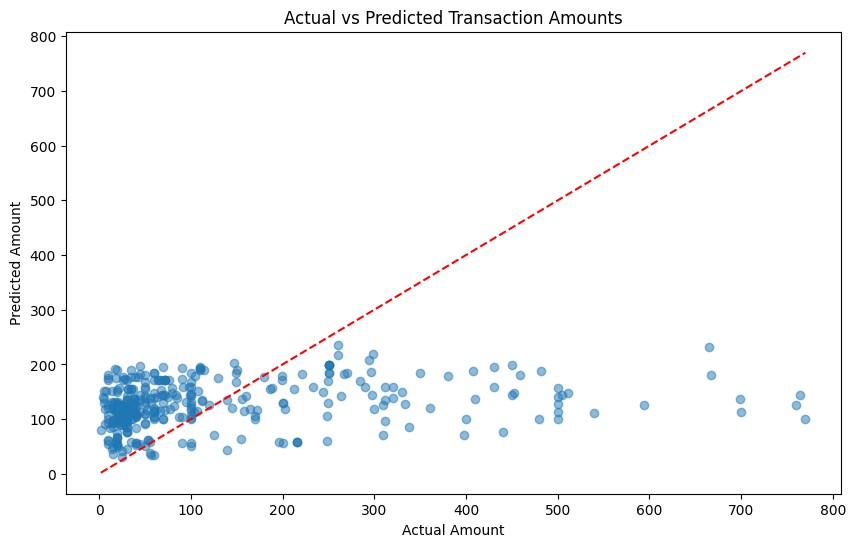

In [64]:
# import machine learning libraries
from sklearn.linear_model import LinearRegression
# Create a linear regression model
model = LinearRegression()
# Train the model
model.fit(X_train, y_train)
# Make predictions on the test set
y_pred = model.predict(X_test)
# Evaluate the model
from sklearn.metrics import mean_squared_error, r2_score
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print("Mean Squared Error:", mse)
print("R-squared:", r2)
# Visualize the model's predictions vs actual values
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--')
plt.title('Actual vs Predicted Transaction Amounts')
plt.xlabel('Actual Amount')
plt.ylabel('Predicted Amount')
plt.show()


In [65]:
# prints score of the model
print("Model Score:", model.score(X_train, y_train))


Model Score: 0.07395830870466047


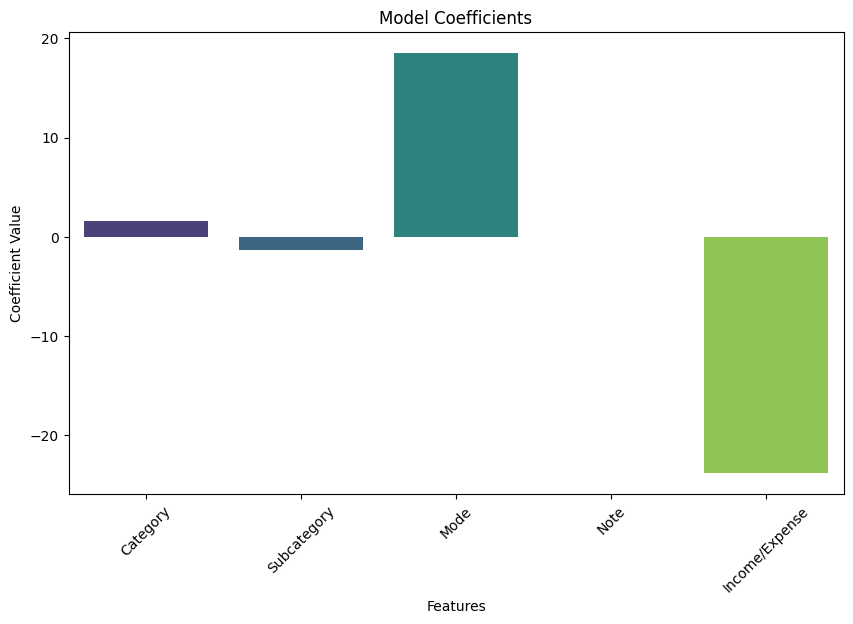

Model Coefficients:
 [  1.57221572  -1.32198318  18.52287475   0.03660767 -23.78273171]


In [69]:
# plot cofficients of the model
coefficients = model.coef_
plt.figure(figsize=(10, 6))
sns.barplot(x=X.columns, y=coefficients, palette='viridis')
plt.title('Model Coefficients')
plt.xlabel('Features')
plt.ylabel('Coefficient Value')
plt.xticks(rotation=45)
plt.show()

print("Model Coefficients:\n", coefficients)

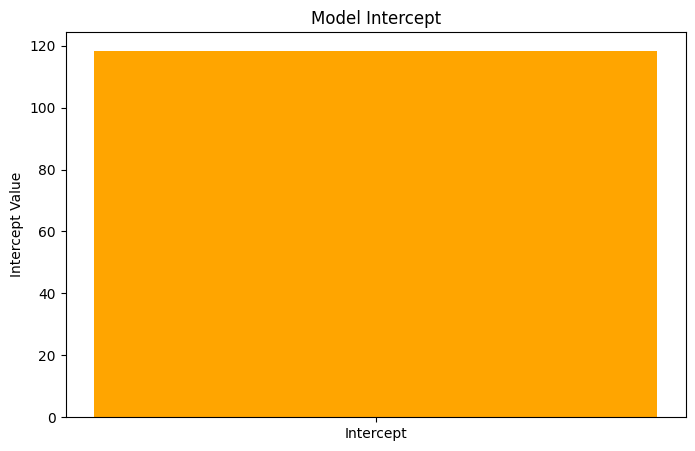

Model Intercept: 118.39164483491756


In [68]:
# plot intercept of the model
intercept = model.intercept_
plt.figure(figsize=(8, 5))
plt.bar(['Intercept'], [intercept], color='orange')
plt.title('Model Intercept')
plt.ylabel('Intercept Value')
plt.show()
print("Model Intercept:", intercept)